In [1]:
# CELL 1
import pandas as pd
import os

# Path to raw file
file_path = os.path.join('..', 'data', 'raw', 'mineral-production-statistics-fy2021-22-to-fy2023-24.xlsx')

# Load and inspect
xl = pd.ExcelFile(file_path)
print("Sheets found:")
for i, name in enumerate(xl.sheet_names):
    print(f"  {i}: {name}")

Sheets found:
  0: About the data
  1: Mined materials produced
  2: Processed materials produced
  3: Contained metals - mined
  4: Contained metals - processed


In [13]:
# CELL 2
# Extract Queensland gold ore throughput from 'Mined materials produced' sheet.
# We filter for Metallic Ore with Gold (Au) as the primary commodity —
# this represents hard rock open-cut mining consistent with Ravenswood's operation.
# The actual header row starts at row 5 (0-indexed), so we skip the first 5 rows.
# Units are in Tonnes('000) so we convert to actual tonnes.

df_mined = pd.read_excel(file_path, sheet_name='Mined materials produced', header=4)

# Filter: Gold primary commodity, Metallic Ore material only
gold_ore = df_mined[
    (df_mined['Primary commodity'] == 'Gold (Au)') &
    (df_mined['Material'] == 'Metallic Ore') &
    (df_mined['Unit'] == "Tonnes('000)")
].copy()

# Convert to actual tonnes
gold_ore['quantity_tonnes'] = pd.to_numeric(
    gold_ore['Material quantity'], errors='coerce') * 1000

# Aggregate by financial year (multiple rows per year from different operations)
ore_throughput = gold_ore.groupby('Financial year')['quantity_tonnes'].sum().reset_index()
ore_throughput.columns = ['financial_year', 'ore_throughput_tonnes']

print(ore_throughput)

  financial_year  ore_throughput_tonnes
0        2021-22           8.951016e+06
1        2022-23           1.464259e+07
2        2023-24           1.351549e+07


In [14]:
# CELL 2a — Inspect column names and first few rows before filtering
df_mined = pd.read_excel(file_path, sheet_name='Mined materials produced')
print("Columns:", df_mined.columns.tolist())
print()
print(df_mined.head(3))

Columns: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6']

                                          Unnamed: 0 Unnamed: 1 Unnamed: 2  \
0                                                NaN        NaN        NaN   
1                                                NaN        NaN        NaN   
2  Quantity of materials mined, by primary commodity        NaN        NaN   

  Unnamed: 3 Unnamed: 4 Unnamed: 5 Unnamed: 6  
0        NaN        NaN        NaN        NaN  
1        NaN        NaN        NaN        NaN  
2        NaN        NaN        NaN        NaN  


In [15]:
# CELL 2b2 — Check exact column names after skipping header rows
df_mined = pd.read_excel(file_path, sheet_name='Mined materials produced', header=3)
print("Columns:", df_mined.columns.tolist())

Columns: ['Quantity of materials mined, by primary commodity', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6']


In [17]:
# CELL 3
# Filter for Dore with Gold (Au) as primary commodity.
# Dore is the smelted gold-silver alloy produced at the end of the CIP leaching circuit —
# exactly what Ravenswood's processing plant outputs.
# We aggregate by financial year to get total processed output volume.

df_processed = pd.read_excel(file_path, sheet_name='Processed materials produced', header=4)

# Filter: Dore, Gold primary commodity, Tonnes unit only
gold_dore = df_processed[
    (df_processed['Primary commodity'] == 'Gold (Au)') &
    (df_processed['Material'] == 'Dore') &
    (df_processed['Unit'] == 'Tonnes')
].copy()

# Convert to numeric
gold_dore['quantity_tonnes'] = pd.to_numeric(
    gold_dore['Material quantity'], errors='coerce')

# Aggregate by financial year
dore_output = gold_dore.groupby('Financial year')['quantity_tonnes'].sum().reset_index()
dore_output.columns = ['financial_year', 'dore_output_tonnes']

print(dore_output)

  financial_year  dore_output_tonnes
0        2021-22            9.144774
1        2022-23           13.644081
2        2023-24          164.129136


In [19]:
# CELL 4
# Extract gold ounces contained in mined material from 'Contained metals - mined' sheet.
# This represents the gold content in ore before processing — used later to calculate
# the proxy recovery rate. We normalise mixed units (Troy Ounces vs Troy Ounces '000)
# to a single unit: Troy Ounces, then aggregate by financial year.

df_contained_mined = pd.read_excel(file_path, sheet_name='Contained metals - mined', header=4)

# Filter: Gold only
gold_mined_oz = df_contained_mined[
    df_contained_mined['Commodity contained'] == 'Gold (Au)'
].copy()

# Normalise units to Troy Ounces
gold_mined_oz['quantity_norm'] = pd.to_numeric(
    gold_mined_oz['Commodity quantity'], errors='coerce')

gold_mined_oz.loc[gold_mined_oz['Unit'] == "Troy Ounces ('000)", 'quantity_norm'] *= 1000

# Aggregate by financial year
gold_mined_oz_agg = gold_mined_oz.groupby('Financial year')['quantity_norm'].sum().reset_index()
gold_mined_oz_agg.columns = ['financial_year', 'gold_mined_oz']

print(gold_mined_oz_agg)

  financial_year  gold_mined_oz
0        2021-22   5.253982e+05
1        2022-23   6.192662e+05
2        2023-24   1.234832e+06


In [23]:
# CELL 5 (CORRECTED)
# The processed metals sheet has mixed units across material types —
# some rows are in plain Troy Ounces, others in Troy Ounces ('000).
# We normalise everything to plain Troy Ounces before aggregating,
# consistent with the same approach used in CELL 4 for mined metals.
# Note per the data description: processed quantities may include feedstock
# from outside Queensland, so this is a state-wide proxy, not mine-specific.

df_contained_processed = pd.read_excel(file_path, sheet_name='Contained metals - processed', header=4)

# Filter: Gold only
gold_processed_oz = df_contained_processed[
    df_contained_processed['Commodity contained'] == 'Gold (Au)'
].copy()

# Normalise units to plain Troy Ounces
gold_processed_oz['quantity_norm'] = pd.to_numeric(
    gold_processed_oz['Commodity quantity'], errors='coerce')

gold_processed_oz.loc[
    gold_processed_oz['Unit'] == "Troy Ounces ('000)", 'quantity_norm'
] *= 1000

# Aggregate by financial year
gold_processed_oz_agg = gold_processed_oz.groupby(
    'Financial year')['quantity_norm'].sum().reset_index()
gold_processed_oz_agg.columns = ['financial_year', 'gold_recovered_oz']

print(gold_processed_oz_agg)

  financial_year  gold_recovered_oz
0        2021-22      506483.001873
1        2022-23      607768.615392
2        2023-24      665206.386275


In [24]:
# CELL 6
# Merge all four production tables into a single master production dataframe.
# We then calculate two key derived metrics:
#   1. Ore-to-Dore Ratio: how many tonnes of ore are needed to produce 1 tonne of dore
#   2. Proxy Recovery Rate: gold recovered (processed oz) / gold contained (mined oz) * 100
# These two metrics directly answer the job requirement of modelling recovery rates
# and processing plant performance.

# Merge all four tables on financial year
production_master = ore_throughput.merge(dore_output, on='financial_year', how='left') \
                                  .merge(gold_mined_oz_agg, on='financial_year', how='left') \
                                  .merge(gold_processed_oz_agg, on='financial_year', how='left')

# Calculate derived metrics
production_master['ore_to_dore_ratio'] = (
    production_master['ore_throughput_tonnes'] / production_master['dore_output_tonnes']
)

production_master['recovery_rate_pct'] = (
    production_master['gold_recovered_oz'] / production_master['gold_mined_oz'] * 100
).round(2)

# Round large numbers for readability
production_master['ore_throughput_tonnes'] = production_master['ore_throughput_tonnes'].round(0)
production_master['gold_mined_oz'] = production_master['gold_mined_oz'].round(0)
production_master['gold_recovered_oz'] = production_master['gold_recovered_oz'].round(2)
production_master['ore_to_dore_ratio'] = production_master['ore_to_dore_ratio'].round(0)

print(production_master.to_string(index=False))

financial_year  ore_throughput_tonnes  dore_output_tonnes  gold_mined_oz  gold_recovered_oz  ore_to_dore_ratio  recovery_rate_pct
       2021-22              8951016.0            9.144774       525398.0          506483.00           978812.0              96.40
       2022-23             14642594.0           13.644081       619266.0          607768.62          1073183.0              98.14
       2023-24             13515493.0          164.129136      1234832.0          665206.39            82347.0              53.87


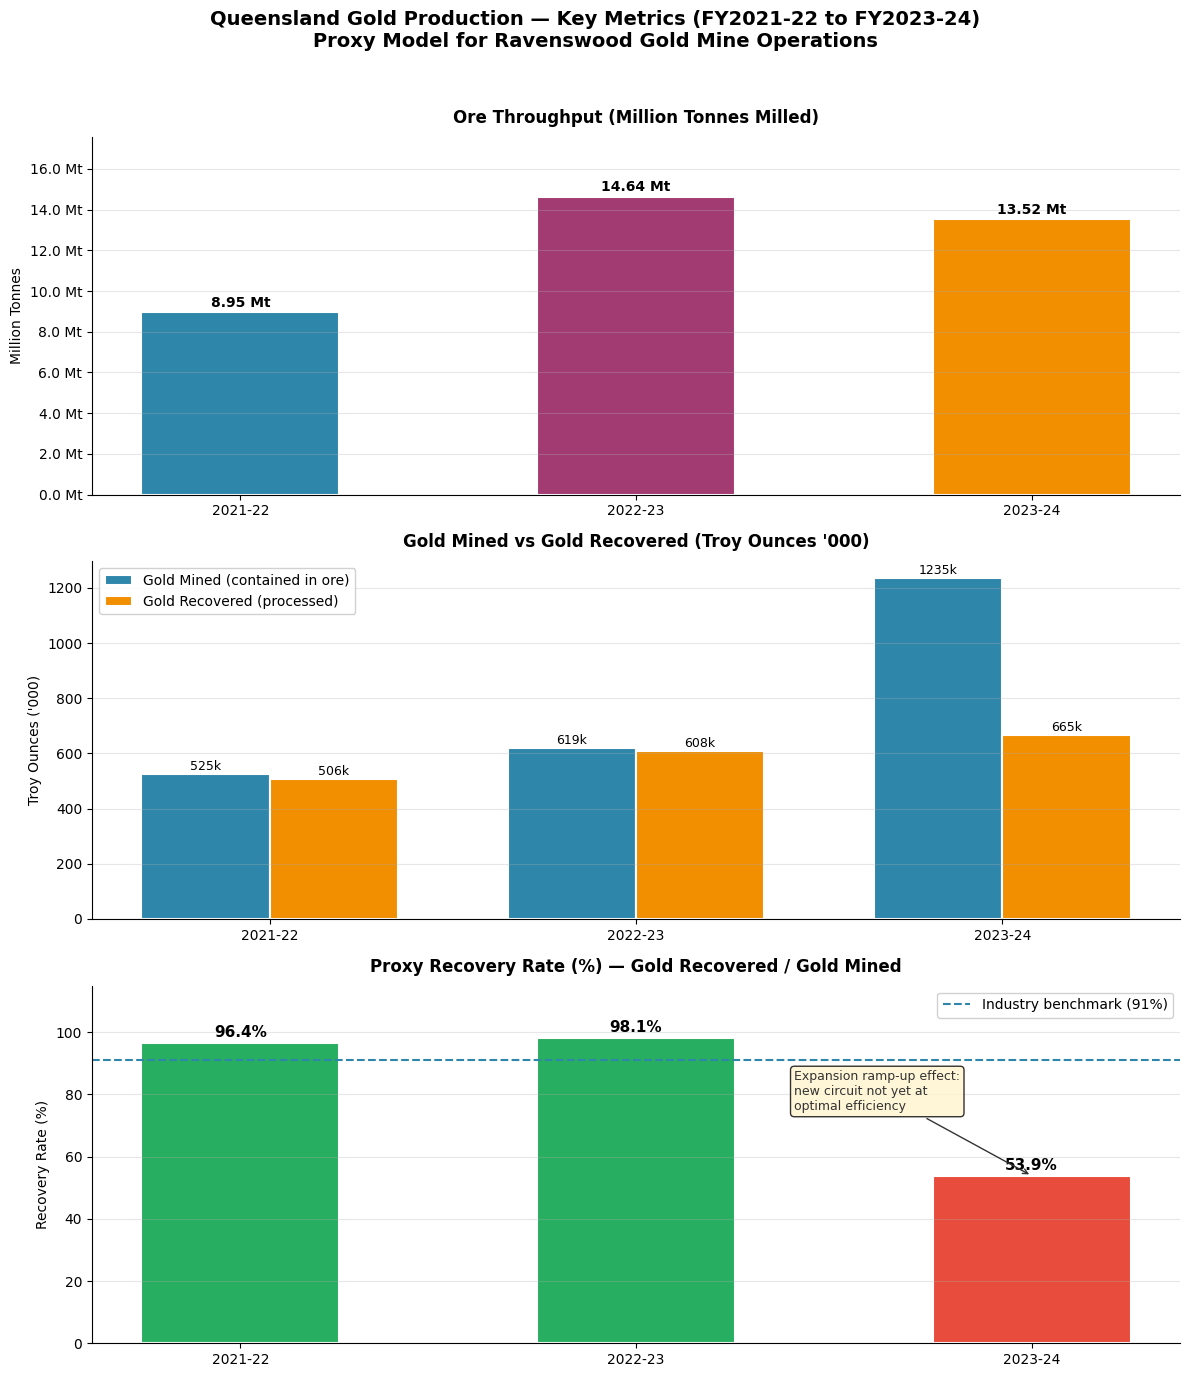

Chart saved to output/01_production_metrics.png
Data saved to data/processed/production/gold_production_qld.csv


In [25]:
# CELL 7
# Visualise the three key production metrics across financial years:
#   1. Ore throughput (tonnes) — plant capacity utilisation proxy
#   2. Gold mined vs recovered (troy oz) — recovery efficiency
#   3. Recovery rate (%) — single headline KPI
# Then save the production master table to the processed data folder.

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

fig, axes = plt.subplots(3, 1, figsize=(12, 14))
fig.suptitle('Queensland Gold Production — Key Metrics (FY2021-22 to FY2023-24)\nProxy Model for Ravenswood Gold Mine Operations',
             fontsize=14, fontweight='bold', y=0.98)

years = production_master['financial_year']
x = range(len(years))

# --- Chart 1: Ore Throughput ---
ax1 = axes[0]
bars1 = ax1.bar(x, production_master['ore_throughput_tonnes'] / 1e6,
                color=['#2E86AB', '#A23B72', '#F18F01'],
                width=0.5, edgecolor='white', linewidth=1.5)
ax1.set_title('Ore Throughput (Million Tonnes Milled)', fontweight='bold', pad=10)
ax1.set_ylabel('Million Tonnes')
ax1.set_xticks(x)
ax1.set_xticklabels(years)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f Mt'))
for bar, val in zip(bars1, production_master['ore_throughput_tonnes']):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.1,
             f'{val/1e6:.2f} Mt',
             ha='center', va='bottom', fontweight='bold', fontsize=10)
ax1.set_ylim(0, production_master['ore_throughput_tonnes'].max() / 1e6 * 1.2)
ax1.grid(axis='y', alpha=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# --- Chart 2: Gold Mined vs Recovered ---
ax2 = axes[1]
width = 0.35
x2 = list(x)
bars_mined = ax2.bar([i - width/2 for i in x2],
                      production_master['gold_mined_oz'] / 1000,
                      width=width, label='Gold Mined (contained in ore)',
                      color='#2E86AB', edgecolor='white', linewidth=1.5)
bars_recovered = ax2.bar([i + width/2 for i in x2],
                          production_master['gold_recovered_oz'] / 1000,
                          width=width, label='Gold Recovered (processed)',
                          color='#F18F01', edgecolor='white', linewidth=1.5)
ax2.set_title("Gold Mined vs Gold Recovered (Troy Ounces '000)", fontweight='bold', pad=10)
ax2.set_ylabel("Troy Ounces ('000)")
ax2.set_xticks(x2)
ax2.set_xticklabels(years)
ax2.legend(loc='upper left', framealpha=0.9)
for bar in bars_mined:
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 5,
             f"{bar.get_height():.0f}k",
             ha='center', va='bottom', fontsize=9)
for bar in bars_recovered:
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 5,
             f"{bar.get_height():.0f}k",
             ha='center', va='bottom', fontsize=9)
ax2.grid(axis='y', alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# --- Chart 3: Recovery Rate ---
ax3 = axes[2]
colors_rr = ['#27AE60' if r >= 90 else '#E74C3C'
             for r in production_master['recovery_rate_pct']]
bars3 = ax3.bar(x, production_master['recovery_rate_pct'],
                color=colors_rr, width=0.5,
                edgecolor='white', linewidth=1.5)
ax3.axhline(y=91, color='#2E86AB', linestyle='--',
            linewidth=1.5, label='Industry benchmark (91%)')
ax3.set_title('Proxy Recovery Rate (%) — Gold Recovered / Gold Mined',
              fontweight='bold', pad=10)
ax3.set_ylabel('Recovery Rate (%)')
ax3.set_xticks(x)
ax3.set_xticklabels(years)
ax3.set_ylim(0, 115)
ax3.legend(loc='upper right', framealpha=0.9)
for bar, val in zip(bars3, production_master['recovery_rate_pct']):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f'{val:.1f}%',
             ha='center', va='bottom', fontweight='bold', fontsize=11)
ax3.grid(axis='y', alpha=0.3)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# Annotation for 2023-24 drop
ax3.annotate('Expansion ramp-up effect:\nnew circuit not yet at\noptimal efficiency',
             xy=(2, production_master['recovery_rate_pct'].iloc[2]),
             xytext=(1.4, 75),
             arrowprops=dict(arrowstyle='->', color='#333333'),
             fontsize=9, color='#333333',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFF3CD', alpha=0.8))

plt.tight_layout(rect=[0, 0, 1, 0.96])

# Save visualisation
output_dir = os.path.join('..', 'output')
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, '01_production_metrics.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to output/01_production_metrics.png")

# Save production master to processed folder
processed_dir = os.path.join('..', 'data', 'processed', 'production')
os.makedirs(processed_dir, exist_ok=True)
production_master.to_csv(
    os.path.join(processed_dir, 'gold_production_qld.csv'), index=False)
print("Data saved to data/processed/production/gold_production_qld.csv")